<a href="https://colab.research.google.com/github/z-serra/PythonNotes4ML/blob/main/LinearRegressionNotes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("https://raw.githubusercontent.com/mofasa-20/USA-Housing/refs/heads/main/USA_Housing.csv")

df.head()

,Area Income,Area House Age,Area No of Rooms,Area No of Bedrooms,Area Population,Price
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Area Income          5000 non-null   float64
 1   Area House Age       5000 non-null   float64
 2   Area No of Rooms     5000 non-null   float64
 3   Area No of Bedrooms  5000 non-null   float64
 4   Area Population      5000 non-null   float64
 5   Price                5000 non-null   float64
dtypes: float64(6)
memory usage: 234.5 KB


In [3]:
df.describe()

,Area Income,Area House Age,Area No of Rooms,Area No of Bedrooms,Area Population,Price
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5.000000e+03
mean,68583.108984,5.977222,6.987792,3.981330,36163.516039,1.232073e+06
std,10657.991214,0.991456,1.005833,1.234137,9925.650114,3.531176e+05
min,17796.631190,2.644304,3.236194,2.000000,172.610686,1.593866e+04
25%,61480.562390,5.322283,6.299250,3.140000,29403.928700,9.975771e+05
50%,68804.286405,5.970429,7.002902,4.050000,36199.406690,1.232669e+06
75%,75783.338665,6.650808,7.665871,4.490000,42861.290770,1.471210e+06
max,107701.748400,9.519088,10.759588,6.500000,69621.713380,2.469066e+06


In [4]:
df.columns

Index(['Area Income', 'Area House Age', 'Area No of Rooms',
       'Area No of Bedrooms', 'Area Population', 'Price'],
      dtype='object')

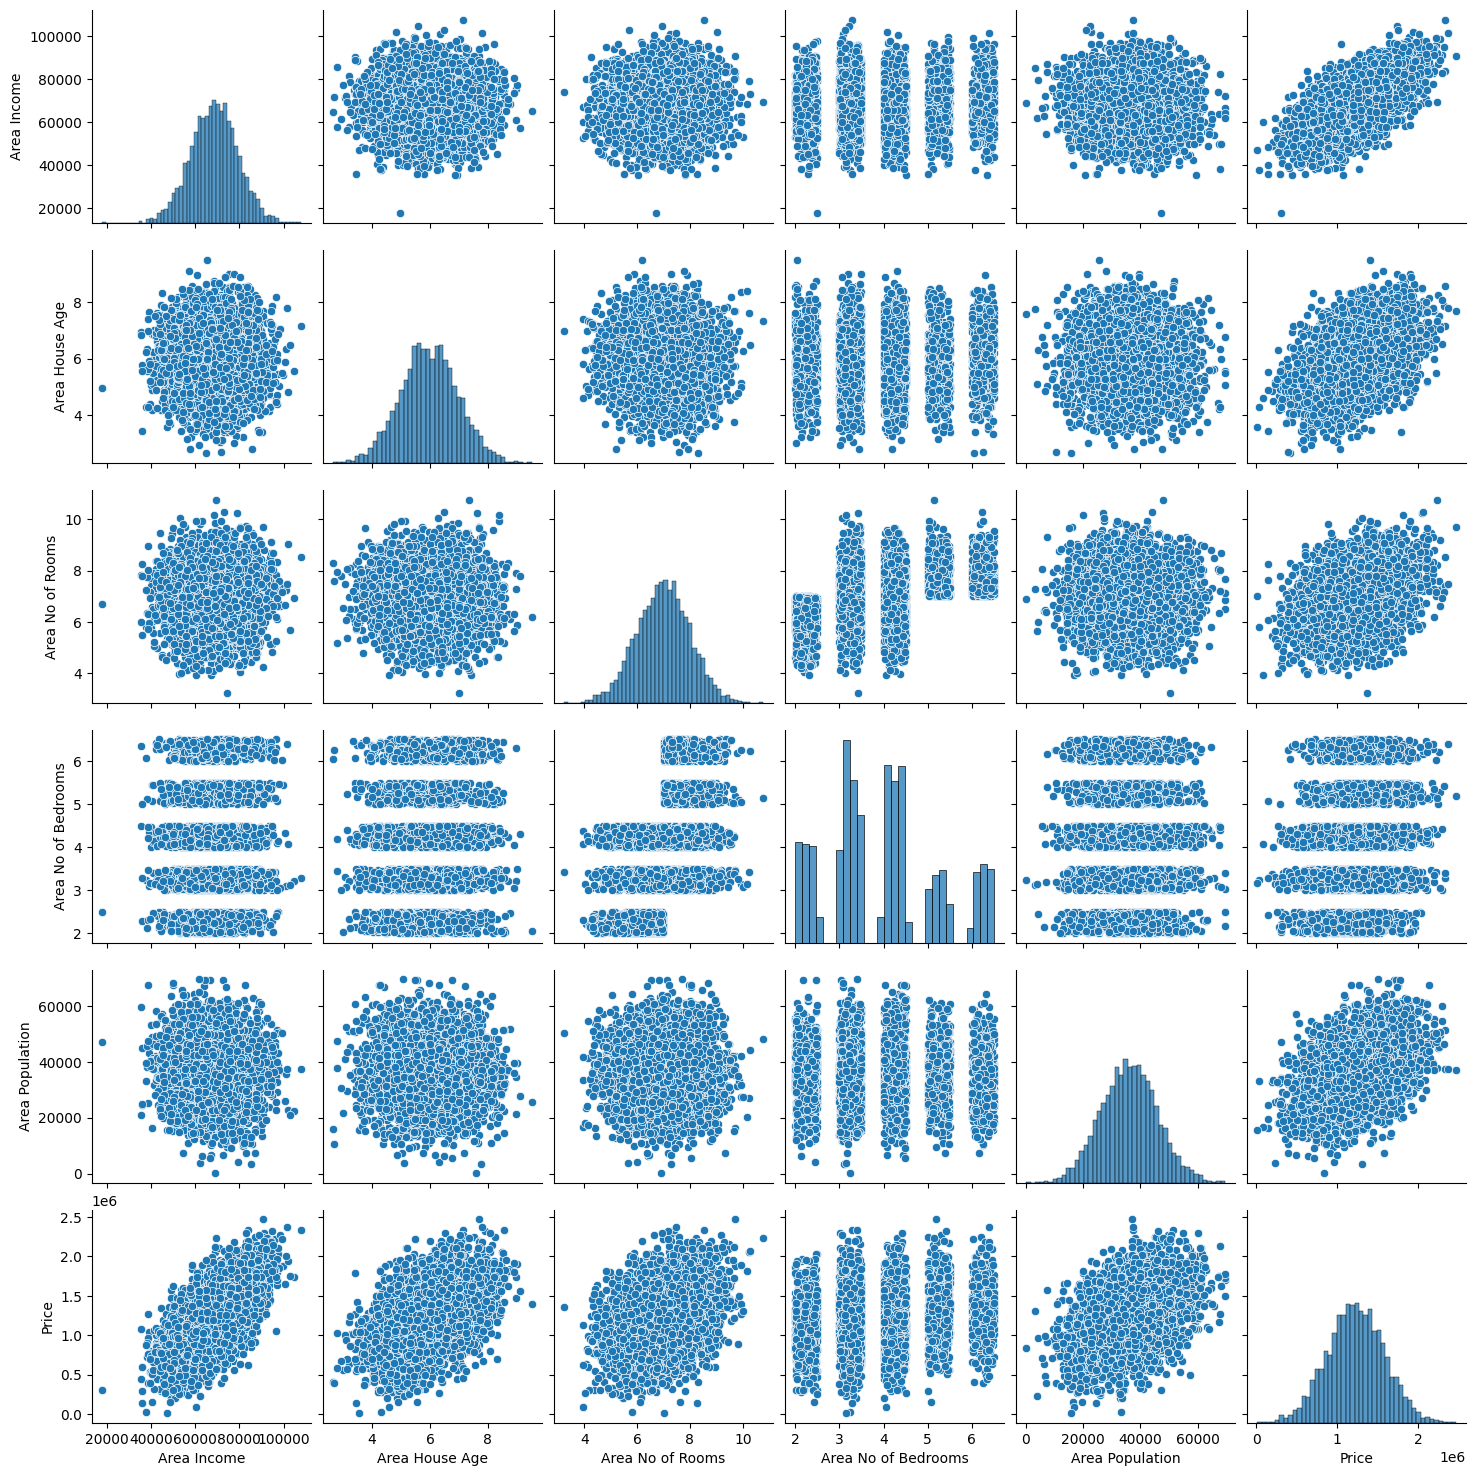

In [5]:
sns.pairplot(df)

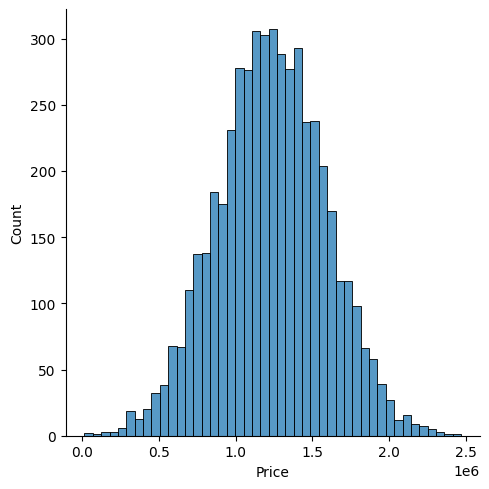

In [6]:
sns.displot(df["Price"])

<Axes: >

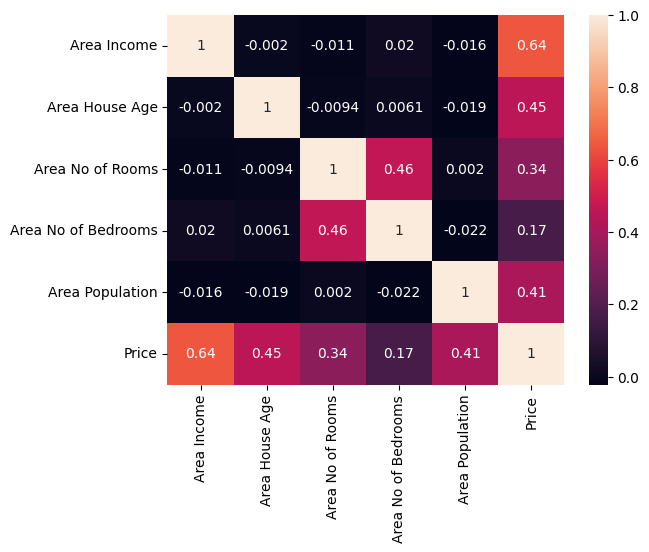

In [7]:
sns.heatmap(df.corr(), annot=True)

In [8]:
X = df[['Area Income', 'Area House Age', 'Area No of Rooms',
       'Area No of Bedrooms', 'Area Population']]

y = df['Price']

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [10]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [11]:
model.intercept_, model.coef_

(np.float64(-2638142.110428253),
 array([2.15898874e+01, 1.66102501e+05, 1.19895936e+05, 1.90107101e+03,
        1.52315025e+01]))

In [12]:
pd.DataFrame(model.coef_, X.columns, columns=['Coef'])

,Coef
Area Income,21.589887
Area House Age,166102.501246
Area No of Rooms,119895.936402
Area No of Bedrooms,1901.071014
Area Population,15.231503


In [13]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

raw_df.head()

<>:2: SyntaxWarning: invalid escape sequence '\s'
<>:2: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_23603/1891692390.py:2: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


,0,1,2,3,4,5,6,7,8,9,10
0,0.00632,18.00,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3
1,396.90000,4.98,24.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.02731,0.00,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8
3,396.90000,9.14,21.60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.02729,0.00,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8


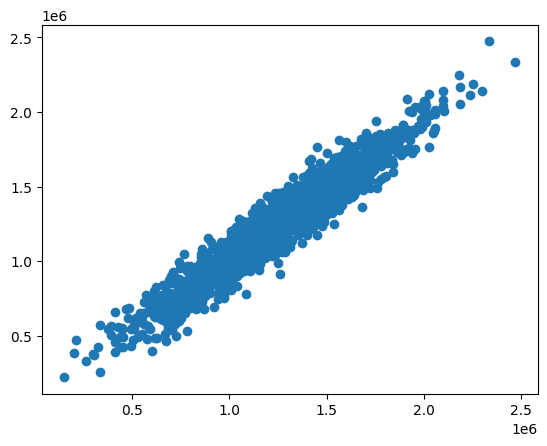

In [14]:
predictions = model.predict(X_test)

plt.scatter(y_test, predictions)

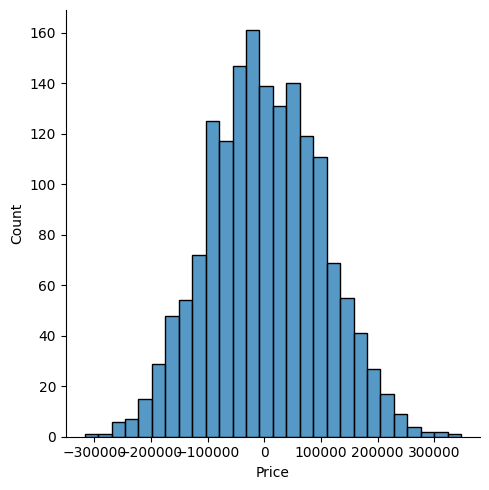

In [15]:
sns.displot((y_test - predictions))

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error

print('MAE: ', mean_absolute_error(y_test, predictions))
print('MSE: ', mean_squared_error(y_test, predictions))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, predictions)))

MAE:  80893.81189972565
MSE:  10013679977.760069
RMSE:  100068.37651206333


In [17]:
df = pd.read_csv("https://raw.githubusercontent.com/Ravjot03/E-Commerce-Customers-Project/refs/heads/master/Ecommerce%20Customers.csv")
df.head()

,Email,Address,Avatar,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
0,mstephenson@fernandez.com,"835 Frank Tunnel\nWrightmouth, MI 82180-9605",Violet,34.497268,12.655651,39.577668,4.082621,587.951054
1,hduke@hotmail.com,"4547 Archer Common\nDiazchester, CA 06566-8576",DarkGreen,31.926272,11.109461,37.268959,2.664034,392.204933
2,pallen@yahoo.com,"24645 Valerie Unions Suite 582\nCobbborough, D...",Bisque,33.000915,11.330278,37.110597,4.104543,487.547505
3,riverarebecca@gmail.com,"1414 David Throughway\nPort Jason, OH 22070-1220",SaddleBrown,34.305557,13.717514,36.721283,3.120179,581.852344
4,mstephens@davidson-herman.com,"14023 Rodriguez Passage\nPort Jacobville, PR 3...",MediumAquaMarine,33.330673,12.795189,37.536653,4.446308,599.406092


In [18]:
df.describe()

,Avg. Session Length,Time on App,Time on Website,Length of Membership,Yearly Amount Spent
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,33.053194,12.052488,37.060445,3.533462,499.314038
std,0.992563,0.994216,1.010489,0.999278,79.314782
min,29.532429,8.508152,33.913847,0.269901,256.670582
25%,32.341822,11.388153,36.349257,2.930450,445.038277
50%,33.082008,11.983231,37.069367,3.533975,498.887875
75%,33.711985,12.753850,37.716432,4.126502,549.313828
max,36.139662,15.126994,40.005182,6.922689,765.518462


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Email                 500 non-null    object 
 1   Address               500 non-null    object 
 2   Avatar                500 non-null    object 
 3   Avg. Session Length   500 non-null    float64
 4   Time on App           500 non-null    float64
 5   Time on Website       500 non-null    float64
 6   Length of Membership  500 non-null    float64
 7   Yearly Amount Spent   500 non-null    float64
dtypes: float64(5), object(3)
memory usage: 31.4+ KB


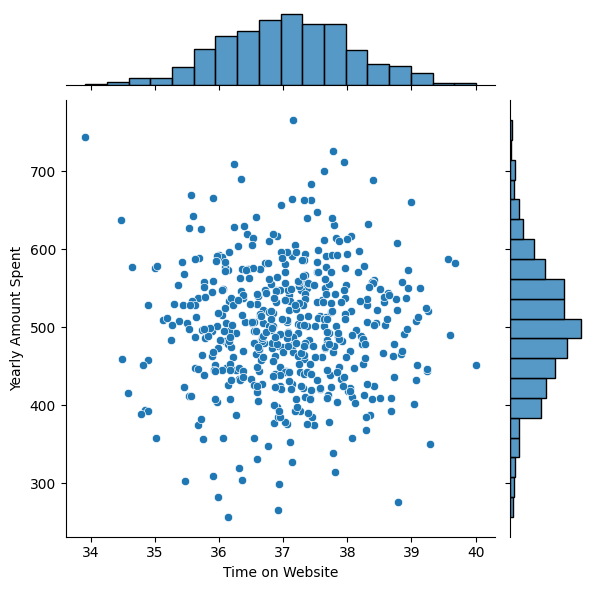

In [20]:
sns.jointplot(x=df['Time on Website'], y=df['Yearly Amount Spent'])

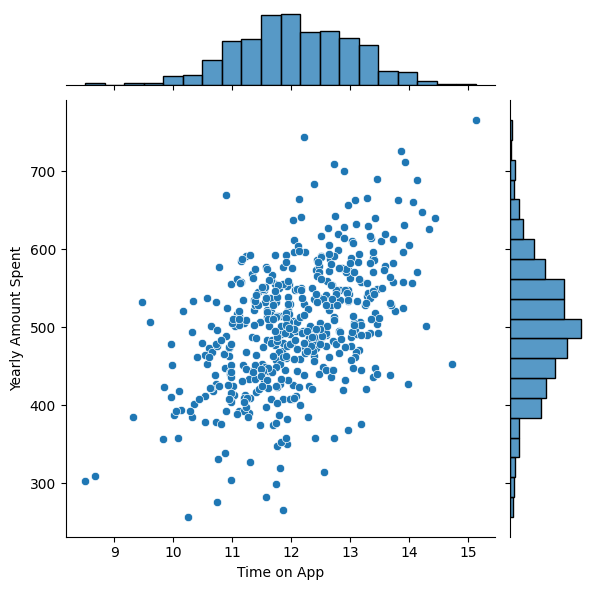

In [21]:
sns.jointplot(x=df['Time on App'], y=df['Yearly Amount Spent'])

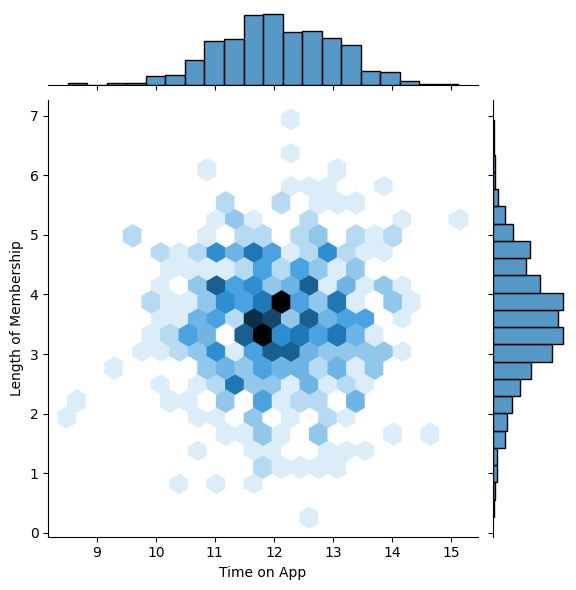

In [22]:
sns.jointplot(x=df['Time on App'], y=df['Length of Membership'], kind='hex')

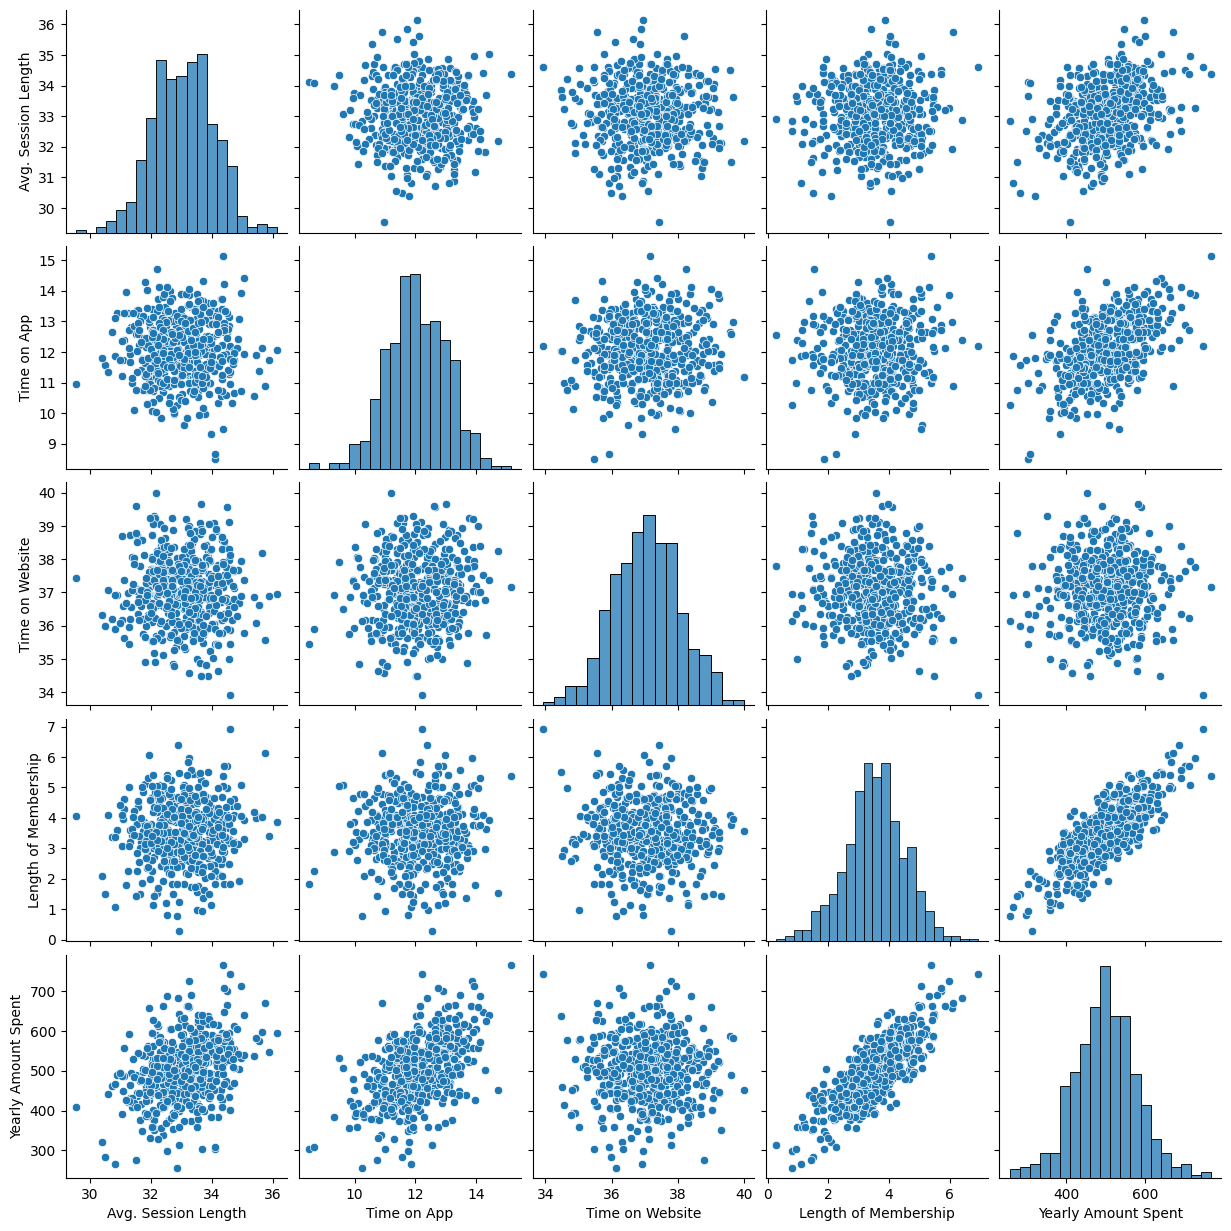

In [23]:
sns.pairplot(df)

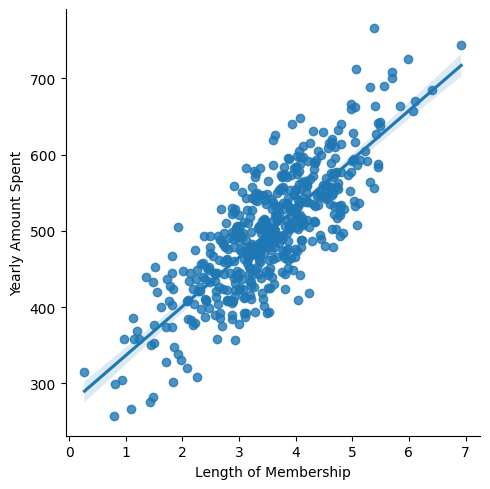

In [24]:
sns.lmplot(y='Yearly Amount Spent', x='Length of Membership', data=df)

In [25]:
df.columns

Index(['Email', 'Address', 'Avatar', 'Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership', 'Yearly Amount Spent'],
      dtype='object')

In [26]:
X = df[['Avg. Session Length', 'Time on App',
       'Time on Website', 'Length of Membership']]

y = df['Yearly Amount Spent']

In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [28]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [29]:
model.coef_

array([25.70676165, 38.57260842,  0.62520092, 61.71767604])

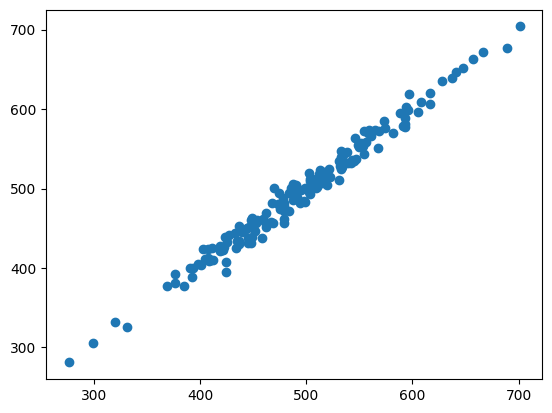

In [30]:
plt.scatter(y_test, model.predict(X_test))

In [31]:
print('MAE: ', mean_absolute_error(y_test, model.predict(X_test)))
print('MSE: ', mean_squared_error(y_test, model.predict(X_test)))
print('RMSE: ', np.sqrt(mean_squared_error(y_test, model.predict(X_test))))

MAE:  8.35357352501759
MSE:  102.4042865993193
RMSE:  10.119500313717042


In [32]:
# r squared (explained variance score)

from sklearn.metrics import explained_variance_score

explained_variance_score(y_test, model.predict(X_test))

0.9814710935431785

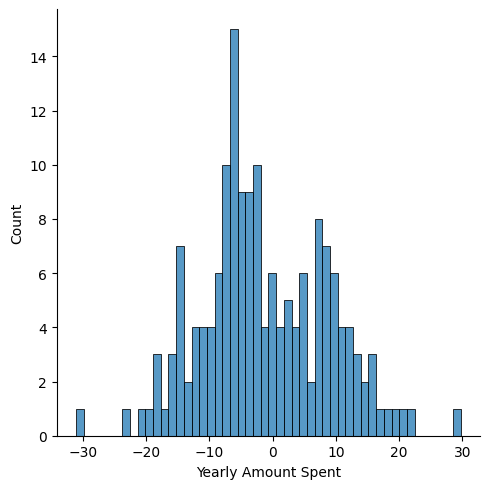

In [33]:
sns.displot((y_test - model.predict(X_test)), bins=50)

In [34]:
pd.DataFrame(model.coef_, X.columns, columns=['Coef'])

,Coef
Avg. Session Length,25.706762
Time on App,38.572608
Time on Website,0.625201
Length of Membership,61.717676
